# Dataset和Dataloader

In [ ]:
!pip list|grep kaggle

kaggle                                   2.0.2
kagglehub                                1.0.2
kagglesdk                                0.1.23


In [ ]:
import json
#username和key改为自己的kaggle的，如果不行，就可以直接用这个
token = {"username":"cromy","key":"KGAT_38ceefebb3ff04a48bc24df71aa0c938"}
with open('/content/kaggle.json', 'w') as file:
  json.dump(token, file)#json.dump类似于write

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content

- path is now set to: /content


In [ ]:
!kaggle datasets download -d slothkong/10-monkey-species

Dataset URL: https://www.kaggle.com/datasets/slothkong/10-monkey-species
License(s): CC0-1.0
10-monkey-species.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o -d /content /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip

Archive:  /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip
  inflating: /content/monkey_labels.txt  
  inflating: /content/training/training/n0/n0018.jpg  
  inflating: /content/training/training/n0/n0019.jpg  
  inflating: /content/training/training/n0/n0020.jpg  
  inflating: /content/training/training/n0/n0021.jpg  
  inflating: /content/training/training/n0/n0022.jpg  
  inflating: /content/training/training/n0/n0023.jpg  
  inflating: /content/training/training/n0/n0024.jpg  
  inflating: /content/training/training/n0/n0025.jpg  
  inflating: /content/training/training/n0/n0026.jpg  
  inflating: /content/training/training/n0/n0027.jpg  
  inflating: /content/training/training/n0/n0028.jpg  
  inflating: /content/training/training/n0/n0029.jpg  
  inflating: /content/training/training/n0/n0030.jpg  
  inflating: /content/training/training/n0/n0031.jpg  
  inflating: /content/training/training/n0/n0032.jpg  
  inflating: /content/training/training/n0/n0033.jpg  


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置数据预处理操作，包括将图片缩放到224x224，并将其转换为Tensor，以及归一化
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.436336, 0.432812, 0.329107],
    std=[0.246400, 0.241861, 0.245292],
),
])

# 使用ImageFolder分别读取训练集和验证集
train_dataset = datasets.ImageFolder(
    root='training/training',  # 指向训练集文件夹
    transform=transform
)
val_dataset = datasets.ImageFolder(
    root='validation/validation',  # 指向验证集文件夹
    transform=transform
)

# 创建训练集和验证集的DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# 示范访问训练集的部分batch
for images, labels in train_loader:
    print("Train batch:", images.shape, labels)
    break  # 只打印第一个batch的内容

# 示范访问验证集的部分batch
for images, labels in val_loader:
    print("Validation batch:", images.shape, labels)
    break  # 只打印第一个batch的内容

Train batch: torch.Size([32, 3, 224, 224]) tensor([4, 4, 5, 1, 1, 3, 9, 1, 1, 3, 4, 7, 4, 6, 3, 8, 5, 3, 4, 2, 1, 5, 4, 1,
        8, 6, 9, 9, 4, 2, 8, 7])
Validation batch: torch.Size([32, 3, 224, 224]) tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1])


In [ ]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
import torch.nn as nn

class SimpleConvNet(nn.Module):
    def __init__(self, num_classes=10):  # 假设分类数为10，可根据实际调整
        super(SimpleConvNet, self).__init__()
        self.features = nn.Sequential(
            # Block 1: Conv -> Conv -> Pool
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: Conv -> Conv -> Pool
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: Conv -> Conv -> Pool
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),  # 输入图片224, 连续3次2x2池化后为28，通道128
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
model = SimpleConvNet()
print(model)

SimpleConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1):

In [ ]:
# 统计模型参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"模型参数总数: {total_params}")

模型参数总数: 4482730


Epoch [1/10], Train Loss: 2.3059, Train Acc: 10.30%, Val Loss: 2.3006, Val Acc: 10.29%
Best model saved at epoch 1.
Epoch [2/10], Train Loss: 2.2834, Train Acc: 15.59%, Val Loss: 2.2212, Val Acc: 13.60%
Best model saved at epoch 2.
Epoch [3/10], Train Loss: 2.1452, Train Acc: 28.35%, Val Loss: 2.0083, Val Acc: 31.25%
Best model saved at epoch 3.
Epoch [4/10], Train Loss: 1.9624, Train Acc: 34.37%, Val Loss: 1.9627, Val Acc: 31.62%
Best model saved at epoch 4.
Epoch [5/10], Train Loss: 1.8442, Train Acc: 35.46%, Val Loss: 1.9406, Val Acc: 28.31%
Best model saved at epoch 5.
Epoch [6/10], Train Loss: 1.6808, Train Acc: 36.74%, Val Loss: 2.2392, Val Acc: 27.57%
No improvement. Early stop counter: 1/5
Epoch [7/10], Train Loss: 1.6015, Train Acc: 55.88%, Val Loss: 1.8004, Val Acc: 40.07%
Best model saved at epoch 7.
Epoch [8/10], Train Loss: 1.4592, Train Acc: 63.72%, Val Loss: 1.6140, Val Acc: 44.49%
Best model saved at epoch 8.
Epoch [9/10], Train Loss: 1.1461, Train Acc: 74.84%, Val Loss

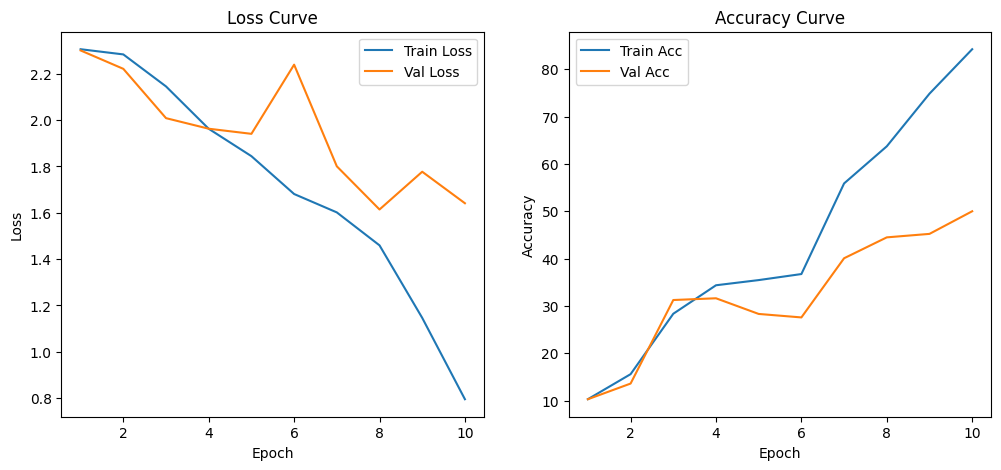

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from model_train import Trainer

# Re-define the SimpleConvNet class with the corrected linear layer input features
class SimpleConvNet(nn.Module):
    def __init__(self, num_classes=10):  # 假设分类数为10，可根据实际调整
        super(SimpleConvNet, self).__init__()
        self.features = nn.Sequential(
            # Block 1: Conv -> Conv -> Pool
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: Conv -> Conv -> Pool
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: Conv -> Conv -> Pool
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),  # Corrected input features: 128 * 28 * 28 = 100352
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Re-instantiate the model with the corrected class definition
model = SimpleConvNet()

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 假设你已经有trainloader和valloader
trainer = Trainer(
    model=model,
    trainloader=train_loader,
    valloader=val_loader,
    optimizer=optimizer,
    device = device,
    early_stop=True,
    patience=5,
    save_path='10monkeys_model.pth'
)

# 训练模型，例如训练10轮
trainer.train(epochs=10)

# 在验证集上评估
val_loss, val_acc = trainer.evaluating(trainer.valloader)
print(f"验证集损失: {val_loss:.4f}, 验证集准确率: {val_acc:.4f}")

# 画出训练和验证过程中的损失与准确率曲线
import matplotlib.pyplot as plt

epochs = range(1, len(trainer.train_losses) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, trainer.train_losses, label='Train Loss')
plt.plot(epochs, trainer.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, trainer.train_accuracies, label='Train Acc')
plt.plot(epochs, trainer.val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()